# CausalTemp-XAI — Full Benchmark Exploration

Walks through every axis of the four-axis evaluation protocol defined in `docs/general_plan.md`:

| Section | Axis | Key outputs |
|---------|------|-------------|
| 1 | — | Data generation, causal graph, VAR mechanisms |
| 2 | — | Classifier training — TCN and LSTM |
| 3 | C | CF generation — 4 third-party backends: NativeGuide, COMTE, CONFETTI (cfts) + CARLA |
| 4 | C | Axis-C metrics: validity, proximity, sparsity, OOD plausibility |
| 5 | C | CF-faith: hard/soft × noiseless-rollout vs Pearl-delta semantics |
| 6 | D | Attribution foil: Integrated Gradients + deletion/insertion curves |
| 7 | A | Concept quality: ICC, MIG, DCI-D/C, MCC |
| 8 | — | End-to-end `evaluate_method` summary table |

> **Config used throughout:** `smoke` (k=5 vars, T=30 steps, N=500 samples) — runs in ~2 min on CPU.  
> **CF dependencies:** `third_party/cfts_repo` submodule + `captum` for NativeGuide.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path

import sys
sys.path.insert(0, str(Path('..').resolve()))

from causaltemp_xai.config import get_config
from causaltemp_xai.data_io import generate_and_save, load_dataset, DEFAULT_OUT_DIR
from causaltemp_xai.benchmark.generator import LinearSCMT
from causaltemp_xai.classifiers import TCNClassifier, LSTMClassifier
from causaltemp_xai.methods.carla import CARLARecourse
from causaltemp_xai.methods.intervention import derive_intervention_t
from causaltemp_xai.methods import (
    CftsNativeGuideCF, CftsCOMTECF, CftsConfetiCF, CftsCelsCF, _DatasetAdapter,
)
from causaltemp_xai.metrics import CFfaith, validity, proximity, sparsity, ood_plausibility
from causaltemp_xai.metrics import icc, mig, dci, mcc
from causaltemp_xai.attribution.integrated_gradients import integrated_gradients
from causaltemp_xai.attribution.perturbation_curves import deletion_curve, insertion_curve
from causaltemp_xai.eval import evaluate_method

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 0
rng = np.random.default_rng(SEED)

# Colour palette that scales with any number of methods
def method_colors(n):
    return [plt.cm.tab10(i) for i in range(n)]

print('Imports OK')

Imports OK


---
## Section 1 · Data — LinearSCM-T

`LinearSCMT` generates a VAR(L) process with a known sparse causal graph.  
Each time series `X[n, t, j]` evolves as:
$$X_t = \sum_{l=1}^{L} A_l X_{t-l} + \varepsilon_t, \quad \varepsilon_t \sim \text{Laplace}$$
Labels are derived from the final-timestep value of the first variable.

In [2]:
cfg = get_config('smoke')   # k=5, L=1, T=30, N=500
print(cfg)

# Generate & cache to disk (idempotent)
out_dir = Path('..') / DEFAULT_OUT_DIR
if not (out_dir / cfg.name / 'meta.json').exists():
    print('Generating dataset…')
    generate_and_save(cfg, out_dir=out_dir)

data = load_dataset(cfg.name, out_dir=out_dir)
X_train, Y_train = data['X_train'], data['Y_train']
X_val,   Y_val   = data['X_val'],   data['Y_val']
X_test,  Y_test  = data['X_test'],  data['Y_test']
graph, mechanisms = data['graph'], data['mechanisms']

print(f"X_train: {X_train.shape}  (N, T, k)")
print(f"graph  : {graph.shape}   (k, k, L)")
print(f"class balance train: {np.bincount(Y_train)}")

BenchmarkConfig(k=5, L=1, sparsity=0.2, noise_type='laplace', T=30, N=500, seed=0, name='smoke')
X_train: (300, 30, 5)  (N, T, k)
graph  : (5, 5, 1)   (k, k, L)
class balance train: [150 150]


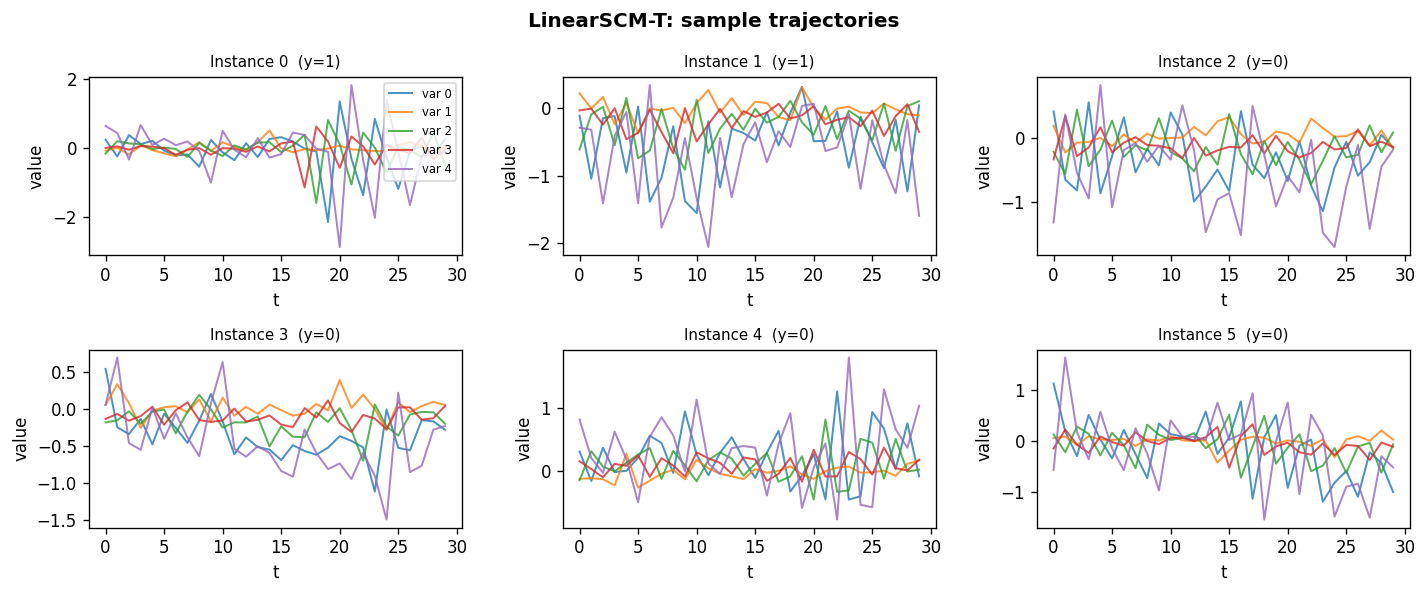

In [3]:
# ── Visualise a few time series ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharey=False)
for idx, ax in enumerate(axes.flat):
    label = Y_train[idx]
    for j in range(cfg.k):
        ax.plot(X_train[idx, :, j], alpha=0.8, linewidth=1.2, label=f'var {j}')
    ax.set_title(f'Instance {idx}  (y={label})', fontsize=9)
    ax.set_xlabel('t'); ax.set_ylabel('value')
axes[0, 0].legend(fontsize=7, loc='upper right')
fig.suptitle('LinearSCM-T: sample trajectories', fontweight='bold')
plt.tight_layout(); plt.show()

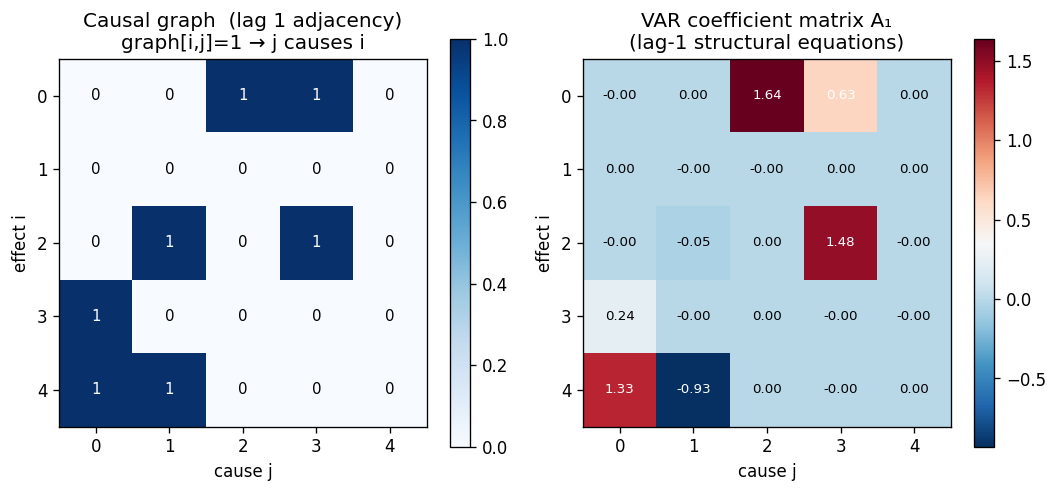

In [4]:
# ── Visualise causal graph and VAR coefficient matrix ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Binary adjacency (k×k) — squeeze over lag dimension
adj = graph[:, :, 0]   # lag-1 adjacency
im0 = axes[0].imshow(adj, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title('Causal graph  (lag 1 adjacency)\ngraph[i,j]=1 → j causes i')
axes[0].set_xlabel('cause j'); axes[0].set_ylabel('effect i')
plt.colorbar(im0, ax=axes[0])
for i in range(cfg.k):
    for j in range(cfg.k):
        axes[0].text(j, i, int(adj[i, j]), ha='center', va='center', fontsize=9,
                     color='white' if adj[i, j] > 0.5 else 'black')

# VAR coefficients
A = mechanisms[0]   # first-lag coefficient matrix
im1 = axes[1].imshow(A, cmap='RdBu_r', interpolation='nearest')
axes[1].set_title('VAR coefficient matrix A₁\n(lag-1 structural equations)')
axes[1].set_xlabel('cause j'); axes[1].set_ylabel('effect i')
plt.colorbar(im1, ax=axes[1])
for i in range(cfg.k):
    for j in range(cfg.k):
        axes[1].text(j, i, f'{A[i,j]:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(A[i,j]) > 0.4 else 'black')

plt.tight_layout(); plt.show()

---
## Section 2 · Classifiers — TCN and LSTM

Both classifiers expose an identical sklearn-style API (`fit`, `predict`, `score`, `torch_logits`)  
and accept `(N, T, k)` arrays — the same layout as the generator output.

In [5]:
tcn = TCNClassifier(
    n_inputs=cfg.k, n_classes=2,
    n_levels=3, n_channels=32, dropout=0.1,
    max_epochs=60, patience=10, seed=SEED,
)
tcn.fit(X_train, Y_train, X_val, Y_val, verbose=False)

lstm = LSTMClassifier(
    n_inputs=cfg.k, n_classes=2,
    hidden_size=32, num_layers=2, dropout=0.1,
    max_epochs=60, patience=10, seed=SEED,
)
lstm.fit(X_train, Y_train, X_val, Y_val, verbose=False)

for name, clf in [('TCN', tcn), ('LSTM', lstm)]:
    tr = clf.score(X_train, Y_train)
    va = clf.score(X_val,   Y_val)
    te = clf.score(X_test,  Y_test)
    print(f'{name}  train={tr:.3f}  val={va:.3f}  test={te:.3f}')

TCN  train=0.767  val=0.740  test=0.640
LSTM  train=0.973  val=0.900  test=0.900


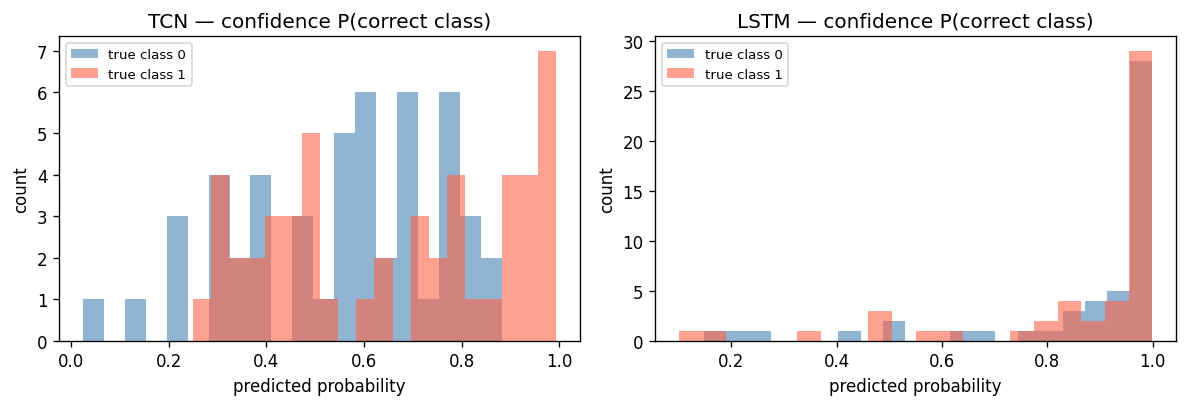

In [6]:
# ── Confidence distribution on test set ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (name, clf) in zip(axes, [('TCN', tcn), ('LSTM', lstm)]):
    proba = clf.predict_proba(X_test)
    for cls, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = Y_test == cls
        ax.hist(proba[mask, cls], bins=20, alpha=0.6, color=color, label=f'true class {cls}')
    ax.set_title(f'{name} — confidence P(correct class)')
    ax.set_xlabel('predicted probability'); ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## Section 3 · Counterfactual Methods — 4 Third-Party Backends

Four CF strategies from the **cfts** and **CARLA** libraries, spanning the full spectrum of inductive biases:

| Method | Library | Strategy | CF-faith expected |
|--------|---------|----------|-------------------|
| **NativeGuide** | cfts | Nearest-unlike-neighbour + GradientShap window swap | Low (no causal graph) |
| **COMTE** | cfts | Shapelet replacement (greedy segment flip) | Low–medium |
| **CONFETTI** | cfts | Genetic algorithm over reference pool | Medium |
| **CARLA** | CARLA | Noiseless VAR rollout after intervention time | High by construction |

> **Dependencies:** cfts methods require the `third_party/cfts_repo` submodule  
> (`git submodule update --init third_party/cfts_repo`).  
> NativeGuide additionally requires `captum` (`pip install captum`).

In [7]:
# Pick 8 test instances predicted as class 0 → ask for class 1 CFs
TARGET = 1
pred_test = tcn.predict(X_test)
candidates = np.where(pred_test != TARGET)[0][:8]
X_orig = X_test[candidates]   # (8, T, k)
print(f'Using {len(candidates)} instances for CF generation')

# Shared reference dataset required by cfts instance-based methods
ds = _DatasetAdapter(X_train, Y_train)

# ── 1. NativeGuide (cfts) ────────────────────────────────────────────────────
# Nearest-unlike-neighbour guide; GradientShap identifies the most influential
# time windows, which are then replaced segment-by-segment with the guide's
# corresponding windows until the prediction flips.
# Requires: captum  (pip install captum)
native_guide = CftsNativeGuideCF(
    target_class=TARGET,
    dataset=ds,
    sub_len=1,          # starting window length for segment search
)

# ── 2. COMTE (cfts) ──────────────────────────────────────────────────────────
# Greedy shapelet replacement: finds the single time-series segment whose
# replacement with the nearest-unlike-neighbour's segment most improves the
# predicted probability toward the target, and repeats until valid.
comte = CftsCOMTECF(
    target_class=TARGET,
    dataset=ds,
)

# ── 3. CONFETTI (cfts) ───────────────────────────────────────────────────────
# Genetic algorithm: maintains a population of CF candidates built from
# sub-sequences sampled from the reference pool; fitness = validity + proximity.
confetti = CftsConfetiCF(
    target_class=TARGET,
    dataset=ds,
    max_iterations=80,
    population_size=40,
    mutation_rate=0.1,
)

# ── 4. CARLARecourse (CARLA) ─────────────────────────────────────────────────
# Gradient optimisation in input space with a noiseless VAR forward rollout
# constraint enforced from the claimed intervention time t₀ onward.
# By construction, hard CF-faith(noiseless_rollout) == 1 for valid CFs.
carla = CARLARecourse(
    target_class=TARGET,
    lam_pred=1.0,
    lam_prox=0.5,
    lr=0.05,
    n_steps=300,
)

print('Generating NativeGuide CFs…')
CFs_native = native_guide.generate_batch(X_orig, lstm)   # cfts wraps lstm model

print('Generating COMTE CFs…')
CFs_comte = comte.generate_batch(X_orig, lstm)

print('Generating CONFETTI CFs…')
CFs_confetti = confetti.generate_batch(X_orig, lstm)

print('Generating CARLA CFs…')
# CARLARecourse uses our TCN via torch_logits; graph + mechanisms drive the rollout
CFs_carla = carla.generate_batch(X_orig, tcn, graph, mechanisms)

all_cfs = {
    'NativeGuide': CFs_native,
    'COMTE':       CFs_comte,
    'CONFETTI':    CFs_confetti,
    'CARLA':       CFs_carla,
}
print('Done.')
for name, cfs in all_cfs.items():
    valid_frac = float(np.mean(tcn.predict(cfs) == TARGET))
    print(f'  {name:<12}  shape={cfs.shape}  validity={valid_frac:.2f}')

Using 8 instances for CF generation
Generating NativeGuide CFs…
Generating COMTE CFs…
Generating CONFETTI CFs…
Generating CARLA CFs…
Done.
  NativeGuide   shape=(8, 30, 5)  validity=0.00
  COMTE         shape=(8, 30, 5)  validity=0.62
  CONFETTI      shape=(8, 30, 5)  validity=0.12
  CARLA         shape=(8, 30, 5)  validity=1.00


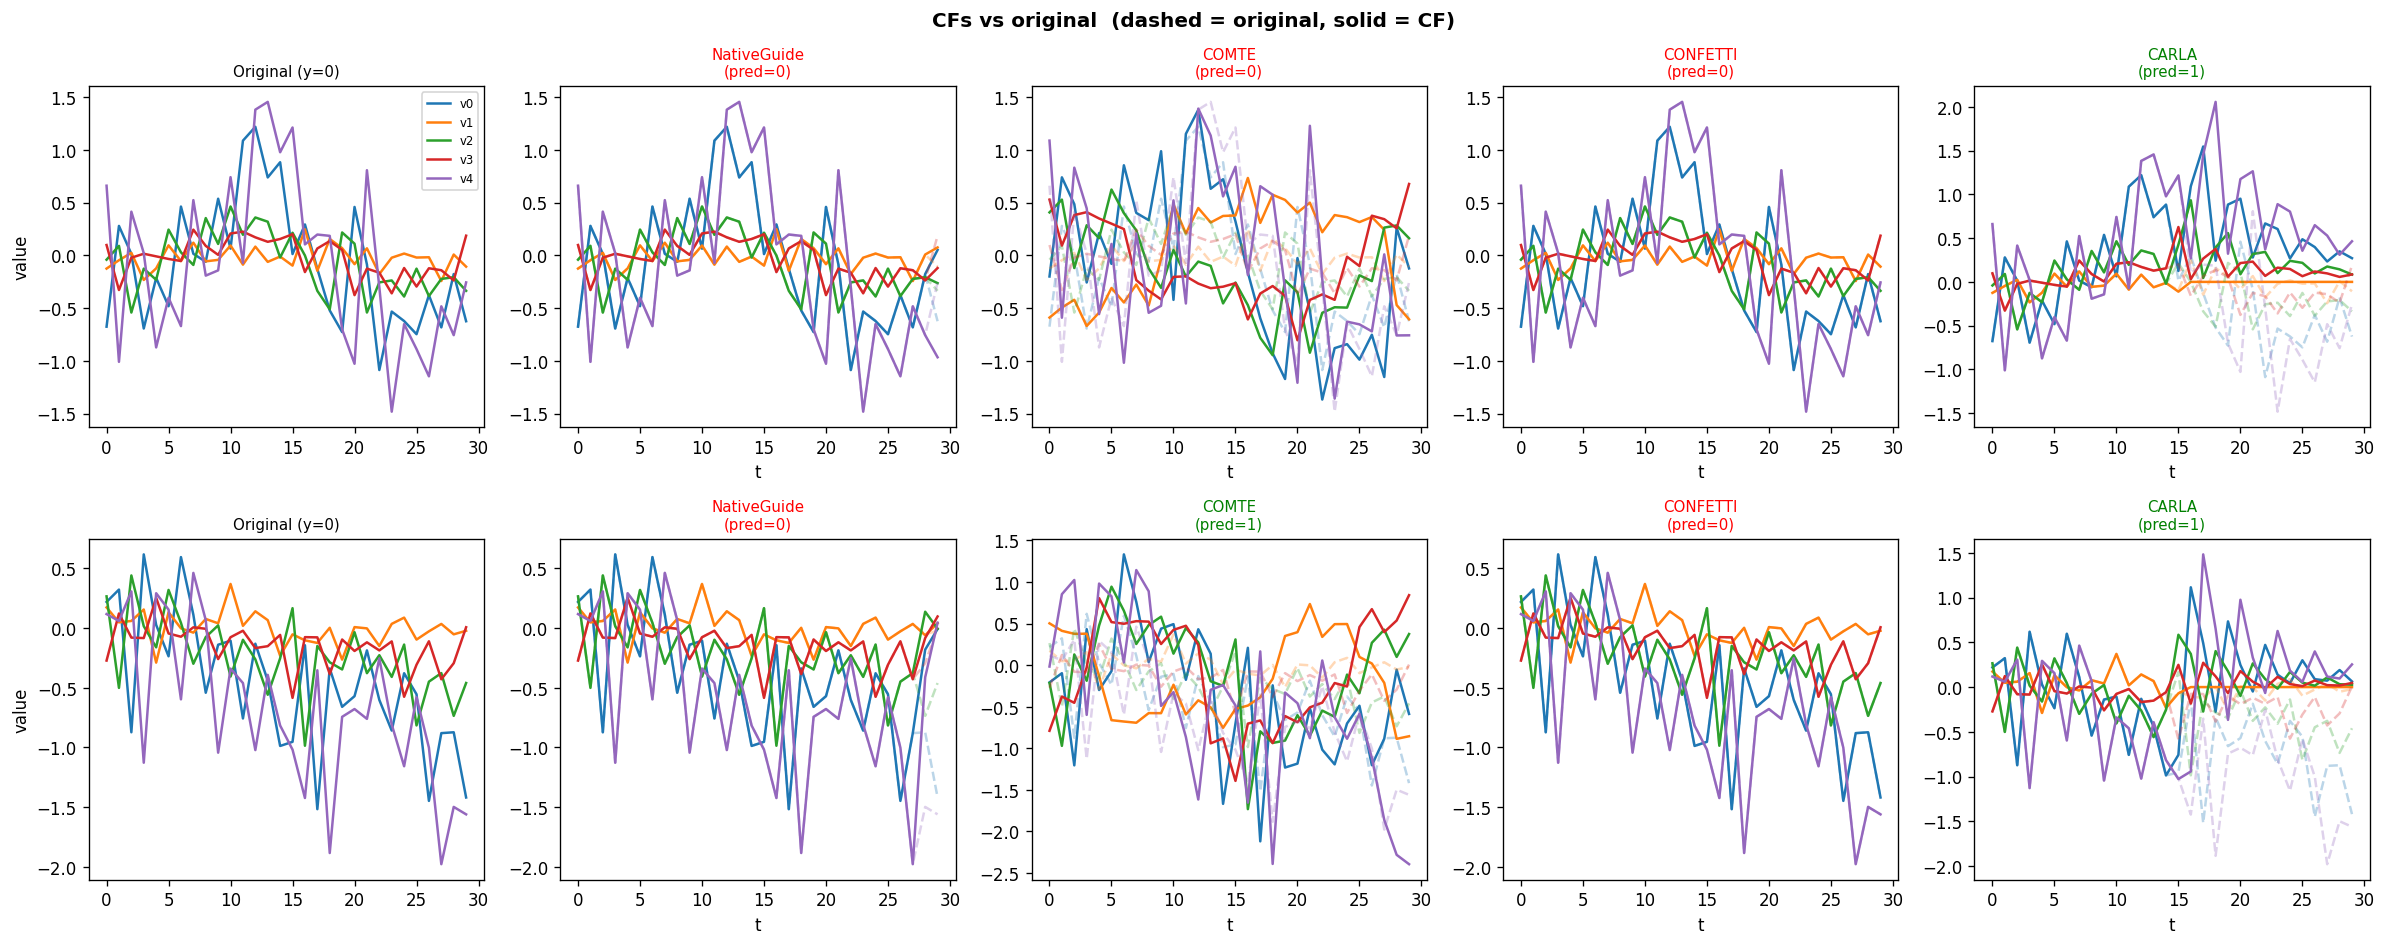

In [8]:
# ── Visualise CFs vs original for first 2 instances ─────────────────────────
# all_cfs is already defined in the cell above with 4 methods
SHOW = 2
n_cols = len(all_cfs) + 1   # 1 original + 4 CFs = 5

fig, axes = plt.subplots(SHOW, n_cols, figsize=(4 * n_cols, 4 * SHOW))
for row in range(SHOW):
    # Original
    ax = axes[row, 0]
    for j in range(cfg.k):
        ax.plot(X_orig[row, :, j], linewidth=1.5, label=f'v{j}')
    ax.set_title(f'Original (y={int(pred_test[candidates[row]])})', fontsize=9)
    ax.set_ylabel('value')
    if row == 0:
        ax.legend(fontsize=7, loc='upper right')

    # Each CF method
    for col, (mname, CFs) in enumerate(all_cfs.items(), start=1):
        ax = axes[row, col]
        for j in range(cfg.k):
            ax.plot(X_orig[row, :, j], linestyle='--', alpha=0.3, color=f'C{j}')
            ax.plot(CFs[row, :, j], linewidth=1.5, color=f'C{j}')
        pred_cf = int(tcn.predict(CFs[row]))
        ax.set_title(f'{mname}\n(pred={pred_cf})', fontsize=9,
                     color='green' if pred_cf == TARGET else 'red')
        ax.set_xlabel('t')

plt.suptitle('CFs vs original  (dashed = original, solid = CF)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 4 · Axis-C Metrics

Four standard counterfactual quality axes evaluated across all four CF methods.

In [ ]:
rows = []
for mname, CFs in all_cfs.items():
    v    = validity(CFs, tcn, target_class=TARGET)
    p_l1 = float(np.mean([proximity(X_orig[i], CFs[i], norm='l1') for i in range(len(X_orig))]))
    p_l2 = float(np.mean([proximity(X_orig[i], CFs[i], norm='l2') for i in range(len(X_orig))]))
    sp   = float(np.mean([sparsity(X_orig[i], CFs[i]) for i in range(len(X_orig))]))
    # ood_plausibility returns an (N,) array for batch input — reduce to a scalar mean
    ood  = float(np.mean(ood_plausibility(X_train, CFs)))
    rows.append({'method': mname, 'validity': v, 'proximity_l1': p_l1,
                 'proximity_l2': p_l2, 'sparsity': sp, 'ood_score': ood})

df_c = pd.DataFrame(rows).set_index('method')
df_c.round(4)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

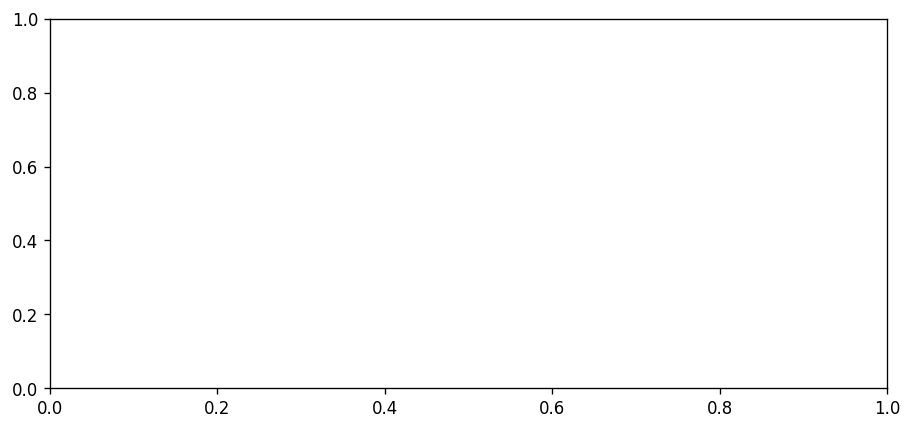

In [10]:
# ── Bar chart for each Axis-C metric ────────────────────────────────────────
metrics_to_plot = ['validity', 'sparsity', 'ood_score']
x = np.arange(len(metrics_to_plot))
methods = list(df_c.index)
n_methods = len(methods)
width = 0.8 / n_methods
colors = method_colors(n_methods)

fig, ax = plt.subplots(figsize=(9, 4))
for i, (mname, color) in enumerate(zip(methods, colors)):
    offset = (i - n_methods / 2 + 0.5) * width
    ax.bar(x + offset, [df_c.loc[mname, m] for m in metrics_to_plot],
           width=width, label=mname, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('score'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=8); ax.set_title('Axis-C metrics by CF method')
ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')
plt.tight_layout(); plt.show()

---
## Section 5 · CF-Faith

**Two semantics** evaluated side-by-side:
- `noiseless_rollout`: the CF is a noiseless VAR rollout from the intervention time (CARLA's construction).
- `pearl_delta`: the CF propagates *only* the intervention delta through the SCM (Pearl's do-calculus).

A single CF cannot satisfy both hard criteria simultaneously — the contrast is the key benchmark finding.

In [ ]:
scorer_rollout = CFfaith(tol=1e-3, scale=1.0, semantics='noiseless_rollout')
scorer_pearl   = CFfaith(tol=1e-3, scale=1.0, semantics='pearl_delta')

faith_rows = []
for mname, CFs in all_cfs.items():
    rollout_hard, rollout_soft = [], []
    pearl_hard,   pearl_soft   = [], []
    for i in range(len(X_orig)):
        t0 = derive_intervention_t(X_orig[i], CFs[i])
        r = scorer_rollout.score(X_orig[i], CFs[i], t0, graph, mechanisms)
        p = scorer_pearl.score(  X_orig[i], CFs[i], t0, graph, mechanisms)
        rollout_hard.append(r['hard']); rollout_soft.append(r['soft'])
        pearl_hard.append(p['hard']);   pearl_soft.append(p['soft'])
    faith_rows.append({
        'method': mname,
        'rollout_hard': np.mean(rollout_hard), 'rollout_soft': np.mean(rollout_soft),
        'pearl_hard':   np.mean(pearl_hard),   'pearl_soft':   np.mean(pearl_soft),
    })

df_faith = pd.DataFrame(faith_rows).set_index('method')
df_faith.round(4)

In [ ]:
# ── Heatmap of CF-faith scores ───────────────────────────────────────────────
n_rows = len(df_faith)
fig, axes = plt.subplots(1, 2, figsize=(10, max(3, n_rows * 0.9)))
for ax, (title, cols) in zip(axes, [
    ('Hard CF-faith',  ['rollout_hard', 'pearl_hard']),
    ('Soft CF-faith',  ['rollout_soft', 'pearl_soft']),
]):
    sub = df_faith[cols]
    im = ax.imshow(sub.values, cmap='YlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(['noiseless_rollout', 'pearl_delta'], fontsize=9)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(sub.index, fontsize=9)
    ax.set_title(title)
    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            ax.text(c, r, f'{sub.values[r, c]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.suptitle('CF-faith by method and semantics', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 6 · Attribution Foil — Integrated Gradients

Integrated Gradients (Sundararajan et al. 2017) attributes each `(t, j)` cell's contribution  
to the classifier's output by integrating gradients along the path from baseline → input.

Completeness axiom: $\sum_{t,j} \phi_{t,j} \approx f_{\text{target}}(x) - f_{\text{target}}(\text{baseline})$

In [ ]:
# Compute IG for the first test instance predicted as class 0
x_ig = X_orig[0]           # (T, k)
baseline = np.zeros_like(x_ig)  # all-zeros baseline

attrs = integrated_gradients(tcn, x_ig, target_class=TARGET, baseline=baseline, steps=50)
print(f'Attribution shape: {attrs.shape}  (T, k)')

# Completeness check
sum_attr = attrs.sum()
delta_f  = tcn.predict_proba(x_ig[None])[0, TARGET] - tcn.predict_proba(baseline[None])[0, TARGET]
print(f'Sum of attrs: {sum_attr:.4f}  |  Δf(x) - Δf(baseline): {delta_f:.4f}')
print(f'Completeness error: {abs(sum_attr - delta_f):.6f}')

In [ ]:
# ── Attribution heatmap + per-variable line ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(attrs.T, cmap='RdBu_r', aspect='auto',
                    vmax=np.abs(attrs).max(), vmin=-np.abs(attrs).max())
axes[0].set_xlabel('time step t'); axes[0].set_ylabel('variable j')
axes[0].set_title('IG attribution heatmap\n(red=positive, blue=negative)')
axes[0].set_yticks(range(cfg.k)); axes[0].set_yticklabels([f'var {j}' for j in range(cfg.k)])
plt.colorbar(im, ax=axes[0])

# Per-variable total absolute attribution
var_attr = np.abs(attrs).sum(axis=0)
axes[1].bar(range(cfg.k), var_attr, color=[f'C{j}' for j in range(cfg.k)], alpha=0.8)
axes[1].set_xlabel('variable j'); axes[1].set_ylabel('total |attribution|')
axes[1].set_title('Total absolute attribution per variable')
axes[1].set_xticks(range(cfg.k))

plt.tight_layout(); plt.show()

In [ ]:
# ── Deletion and insertion curves ────────────────────────────────────────────
del_curve, del_auc = deletion_curve(tcn, x_ig, attrs, TARGET, baseline=baseline)
ins_curve, ins_auc = insertion_curve(tcn, x_ig, attrs, TARGET, baseline=baseline)

fracs = np.linspace(0, 1, len(del_curve))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fracs, del_curve, label=f'Deletion   (AUC={del_auc:.3f})', color='tomato')
ax.plot(fracs, ins_curve, label=f'Insertion  (AUC={ins_auc:.3f})', color='steelblue')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='random baseline')
ax.set_xlabel('fraction of features removed / added')
ax.set_ylabel(f'P(class {TARGET})')
ax.set_title('Deletion & Insertion curves (IG attribution)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

---
## Section 7 · Axis-A — Concept Quality

Axis A evaluates the quality of a **latent concept space** learned by an XAI method  
(e.g. β-VAE, iVAE, LEAP) against the ground-truth generative factors.

Here we use **PCA** as a stand-in encoder/decoder (no trained concept model available  
for smoke config). In a real evaluation, substitute your trained β-VAE or LEAP encoder.

| Metric | What it measures |
|--------|------------------|
| **ICC** | Interventional relevance of each latent to the classifier |
| **MIG** | Mutual information gap — one latent per factor → MIG=1 |
| **DCI-D** | Disentanglement — each latent focused on one factor |
| **DCI-C** | Completeness — each factor captured by one latent |
| **MCC** | Mean correlation coefficient — optimal linear matching |


In [ ]:
from sklearn.decomposition import PCA

d_z = 6   # latent dimensions
N_ax = len(X_train)
X_flat = X_train.reshape(N_ax, -1)   # (N, T*k)

pca = PCA(n_components=d_z, random_state=SEED).fit(X_flat)

def encoder(X):
    return pca.transform(X.reshape(len(X), -1))      # (N, d_z)

def decoder(Z):
    return pca.inverse_transform(Z).reshape(len(Z), cfg.T, cfg.k)  # (N, T, k)

Z_train = encoder(X_train)   # (N, d_z)
print(f'Latent codes shape: {Z_train.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')

In [ ]:
# ── ICC: which latent dimensions causally affect the classifier? ─────────────
icc_scores = icc(X_train[:100], encoder, decoder, tcn, delta=1.0)

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(range(d_z), icc_scores, color=['tomato' if s > 0.1 else 'steelblue' for s in icc_scores])
ax.set_xlabel('latent dimension i'); ax.set_ylabel('ICC score')
ax.set_title('Interventional Concept Consistency (ICC)\n'
             'High = intervening on this dimension flips the classifier')
ax.set_xticks(range(d_z)); ax.set_xticklabels([f'z{i}' for i in range(d_z)])
ax.set_ylim(0, 1)
for bar, val in zip(bars, icc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'ICC scores: {icc_scores.round(3)}')

In [ ]:
# ── MIG, DCI, MCC ────────────────────────────────────────────────────────────
# Ground-truth factors: use the VAR variables' time-averages as proxy
# (stand-in for true latent factors; in a real benchmark use SCM latents)
Z_true = X_train.mean(axis=1)   # (N, k) — mean value per variable

mig_score  = mig(Z_train, Z_true, n_bins=15)
dci_result = dci(Z_train, Z_true, random_state=SEED)
mcc_score  = mcc(Z_train, Z_true)

summary = pd.Series({
    'MIG':   round(mig_score, 4),
    'DCI-D': round(dci_result['disentanglement'], 4),
    'DCI-C': round(dci_result['completeness'], 4),
    'MCC':   round(mcc_score, 4),
}, name='PCA surrogate')
print(summary.to_string())

In [ ]:
# ── DCI importance matrix heatmap ────────────────────────────────────────────
R = dci_result['R']   # (K, d_z)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

im0 = axes[0].imshow(R, cmap='viridis', aspect='auto')
axes[0].set_title('Raw importance R[k,j]')
axes[0].set_xlabel('latent j'); axes[0].set_ylabel('factor k')
plt.colorbar(im0, ax=axes[0])

R_col = R / (R.sum(axis=0, keepdims=True) + 1e-12)
im1 = axes[1].imshow(R_col, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Column-normalised (→ Disentanglement)')
axes[1].set_xlabel('latent j'); axes[1].set_ylabel('factor k')
plt.colorbar(im1, ax=axes[1])

R_row = R / (R.sum(axis=1, keepdims=True) + 1e-12)
im2 = axes[2].imshow(R_row, cmap='Oranges', aspect='auto', vmin=0, vmax=1)
axes[2].set_title('Row-normalised (→ Completeness)')
axes[2].set_xlabel('latent j'); axes[2].set_ylabel('factor k')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('DCI importance matrix', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Scatter: inferred latents vs true factors (top 2 MCC-matched pairs) ─────
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr

corr_mat = np.array([[abs(pearsonr(Z_train[:, j], Z_true[:, k])[0])
                       for k in range(Z_true.shape[1])]
                      for j in range(d_z)])
row_ind, col_ind = linear_sum_assignment(-corr_mat)

n_pairs = min(3, len(row_ind))
fig, axes = plt.subplots(1, n_pairs, figsize=(4 * n_pairs, 3.5))
if n_pairs == 1: axes = [axes]
for ax, (j, k) in zip(axes, zip(row_ind[:n_pairs], col_ind[:n_pairs])):
    r, _ = pearsonr(Z_train[:, j], Z_true[:, k])
    ax.scatter(Z_true[:, k], Z_train[:, j], alpha=0.3, s=8, color='steelblue')
    ax.set_xlabel(f'True factor {k} (var {k} mean)')
    ax.set_ylabel(f'Inferred z{j}')
    ax.set_title(f'|r|={abs(r):.3f}')

plt.suptitle('MCC: optimal latent–factor matching', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 8 · End-to-End `evaluate_method` Summary

`evaluate_method` is the single call that produces the full Axis-C + CF-faith report  
used by `experiments/run_all.py`.

In [ ]:
eval_rows = []
for mname, CFs in all_cfs.items():
    result = evaluate_method(
        tcn, X_orig, CFs, X_train, graph, mechanisms, target_class=TARGET
    )
    result['method'] = mname
    eval_rows.append(result)

df_eval = pd.DataFrame(eval_rows).set_index('method')
# Show key columns
cols = ['validity', 'proximity_l1', 'sparsity', 'ood',
        'cf_faith_rollout_hard', 'cf_faith_rollout_soft',
        'cf_faith_pearl_hard',   'cf_faith_pearl_soft']
df_eval[cols].round(3)

In [ ]:
# ── Grouped bar chart: validity + CF-faith scores ────────────────────────────
plot_cols   = ['validity', 'cf_faith_rollout_soft', 'cf_faith_pearl_soft', 'sparsity']
plot_labels = ['Validity', 'CF-faith\n(rollout)', 'CF-faith\n(pearl)', 'Sparsity']
methods  = list(df_eval.index)
n_methods = len(methods)
x = np.arange(len(plot_cols))
width = 0.8 / n_methods
colors = method_colors(n_methods)

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (mname, color) in enumerate(zip(methods, colors)):
    offset = (i - n_methods / 2 + 0.5) * width
    vals = [df_eval.loc[mname, c] for c in plot_cols]
    ax.bar(x + offset, vals, width=width, label=mname, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(plot_labels)
ax.set_ylim(0, 1.2); ax.set_ylabel('score')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(fontsize=8)
ax.set_title('End-to-end evaluation: Axis-C + CF-faith', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Axis-A summary table ─────────────────────────────────────────────────────
# (PCA surrogate — replace with your trained concept encoder in practice)
print('=== Axis-A (PCA surrogate concept model) ===')
print(summary.to_frame().T.to_string(index=False))

print('\n=== Axis-C + CF-faith (TCN classifier, 8 test instances) ===')
print(df_eval[cols].round(3).to_string())